In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [2]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [4]:

def init_params():
    W1 = np.random.randn(128, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((128, 1))
    W2 = np.random.randn(10, 128) * np.sqrt(2 / 128)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2


def leaky_ReLU(Z, alpha=0.01):
    return np.maximum(alpha * Z, Z)

def leaky_ReLU_deriv(Z, alpha=0.01):
    dZ = np.ones_like(Z)
    dZ[Z < 0] = alpha
    return dZ


def softmax(Z):
    Z -= np.max(Z, axis=0, keepdims=True)  # Stability fix
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = leaky_ReLU(Z1) 
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def one_hot(Y):
    one_hot_Y = np.zeros((Y.max() + 1, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y


def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[1] 
    one_hot_Y = one_hot(Y)
    
    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * dZ2.dot(A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * leaky_ReLU_deriv(Z1)  # Correct activation derivative
    dW1 = (1 / m) * dZ1.dot(X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 -= alpha * dW1
    b1 -= alpha * db1    
    W2 -= alpha * dW2  
    b2 -= alpha * db2    
    return W1, b1, W2, b2


In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[5 2 2 ... 9 2 8] [7 9 0 ... 2 5 3]
0.09770731707317074
Iteration:  10
[8 4 0 ... 1 6 8] [7 9 0 ... 2 5 3]
0.6646829268292683
Iteration:  20
[8 7 0 ... 1 6 7] [7 9 0 ... 2 5 3]
0.7691463414634147
Iteration:  30
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8113658536585366
Iteration:  40
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8332682926829268
Iteration:  50
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8474146341463414
Iteration:  60
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8574390243902439
Iteration:  70
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8655121951219512
Iteration:  80
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8714390243902439
Iteration:  90
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.876780487804878
Iteration:  100
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8806829268292683
Iteration:  110
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.884390243902439
Iteration:  120
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8872926829268293
Iteration:  130
[7 9 0 ... 2 6 7] [7 9 0 ... 2 5 3]
0.8898292682926829
Iteration:  140
[7

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [5]
Label:  5


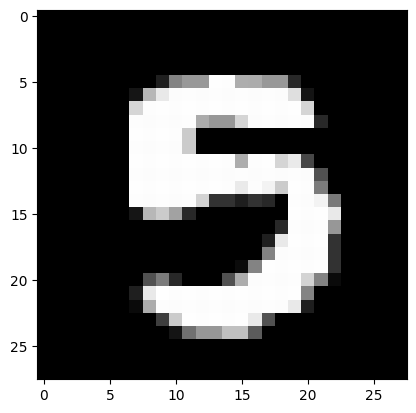

Prediction:  [9]
Label:  9


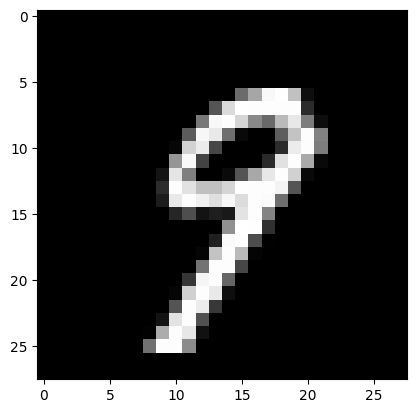

Prediction:  [0]
Label:  0


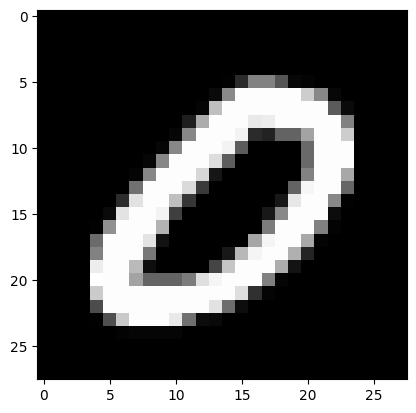

Prediction:  [6]
Label:  6


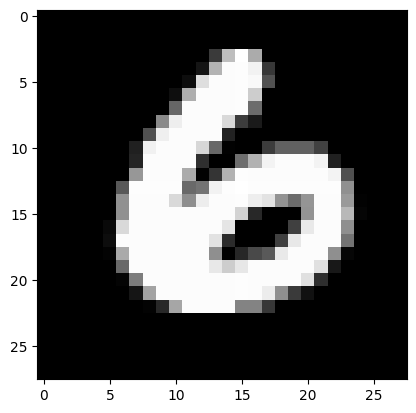

In [8]:
test_prediction(18, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [9]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[2 4 5 2 2 0 4 9 6 3 4 8 9 1 9 4 9 2 0 0 3 1 3 8 5 9 3 8 8 6 0 2 5 7 5 6 4
 1 5 3 4 1 0 3 5 9 7 3 4 4 6 9 2 1 7 6 6 6 3 4 4 5 3 2 0 4 2 0 3 8 2 1 8 1
 9 6 1 7 1 1 9 7 0 5 6 2 9 4 5 4 2 7 1 1 8 0 6 1 5 4 1 1 9 1 9 4 3 7 7 9 5
 9 2 8 6 7 2 9 7 6 4 1 8 1 9 7 4 9 9 5 0 9 8 3 2 8 1 1 8 2 2 3 7 5 3 3 8 6
 8 8 2 2 8 6 1 7 9 0 1 7 6 9 7 2 1 0 1 9 8 7 7 4 9 4 3 8 5 1 0 5 8 5 7 6 8
 4 5 9 6 0 7 8 4 1 0 8 8 4 2 3 8 2 1 5 3 3 3 0 4 2 8 3 5 1 1 3 9 4 9 2 7 7
 5 0 7 3 0 5 9 6 7 7 0 2 9 3 2 2 3 8 1 4 0 8 9 1 0 5 5 3 6 3 3 2 8 0 7 0 5
 3 4 5 3 7 3 9 3 7 1 1 5 1 6 7 8 2 1 7 5 2 0 2 8 2 8 7 3 6 8 0 0 3 0 0 7 4
 1 1 4 6 8 2 0 6 3 2 3 2 6 3 7 4 9 8 3 7 7 8 5 4 2 7 1 5 0 2 3 6 8 7 0 4 0
 8 9 1 8 5 0 8 3 7 1 8 1 3 2 3 8 6 1 4 9 1 2 4 0 6 0 8 4 3 2 6 2 7 7 9 7 7
 0 9 2 0 1 1 6 0 7 4 4 4 7 8 6 2 0 3 3 2 8 6 7 6 9 4 2 2 8 3 9 5 6 7 1 2 7
 6 6 0 4 3 1 3 8 1 7 6 2 3 1 7 8 2 6 8 2 3 4 5 7 0 2 0 3 9 6 7 5 9 0 2 9 2
 8 8 1 4 2 3 9 1 3 2 3 3 3 7 6 3 6 5 5 1 5 0 1 7 9 3 1 9 5 9 7 0 6 5 3 1 3
 4 8 6 4 7 1 0 4 2 1 4 9 

0.921